# Ropedia Academy — B3 · Camera pose: PnP & bundle adjustment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/B3.ipynb)

> **A converging bundle-adjustment loop, visualized two ways: the reprojection-error curve and the 3D points moving from noisy init to the true positions.**
>
> 一个收敛的光束法平差循环，用两种方式可视化：重投影误差曲线，以及 3D 点从含噪初值移动到真实位置。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/B3

final reprojection error: 0.0


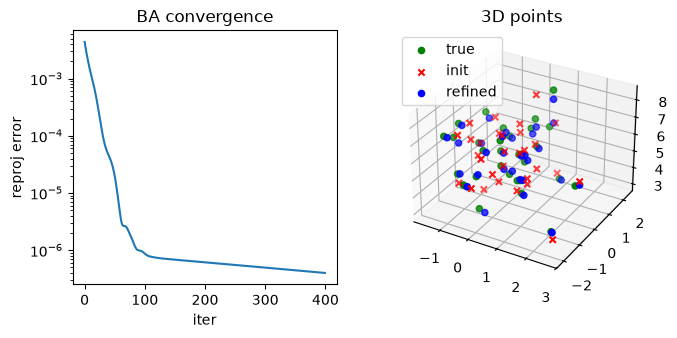

In [1]:
import torch, matplotlib.pyplot as plt
# Bundle Adjustment: jointly refine all poses + points to minimize reprojection.

# ---------- INPUT: true scene + NOISY initial guesses for points & poses ----------
torch.manual_seed(0)
C, P = 3, 30
pts_true = torch.randn(P, 3) + torch.tensor([0,0,5.])
rot = torch.eye(3).expand(C, 3, 3); trans_true = torch.randn(C, 3) * 0.1
project = lambda pts, R, tr: (pts @ R.T + tr)[:, :2] / (pts @ R.T + tr)[:, 2:3]
obs = torch.stack([project(pts_true, rot[c], trans_true[c]) for c in range(C)])
pts   = (pts_true + 0.3*torch.randn_like(pts_true)).requires_grad_()
trans = (trans_true + 0.1*torch.randn_like(trans_true)).requires_grad_()
start = pts.detach().clone()

# ---------- MODEL: descend total reprojection error over points + poses ----------
opt = torch.optim.Adam([pts, trans], lr=0.02); hist = []
for _ in range(400):
    opt.zero_grad()
    loss = ((torch.stack([project(pts, rot[c], trans[c]) for c in range(C)]) - obs)**2).mean()
    loss.backward(); opt.step(); hist.append(loss.item())

# ---------- OUTPUT: convergence curve + points moving init -> truth ----------
print("final reprojection error:", round(hist[-1], 6))
fig = plt.figure(figsize=(7.5, 3.3))
ax = fig.add_subplot(1,2,1); ax.plot(hist); ax.set_yscale('log')
ax.set_title("BA convergence"); ax.set_xlabel("iter"); ax.set_ylabel("reproj error")
ax = fig.add_subplot(1,2,2, projection='3d')
ax.scatter(*pts_true.T, c='g', s=20, label='true'); ax.scatter(*start.T.numpy(), c='r', marker='x', s=20, label='init')
ax.scatter(*pts.detach().T, c='b', s=20, label='refined'); ax.legend(); ax.set_title("3D points")
plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/B3
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks